In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd
from numba import  njit

# Примеры

In [3]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Execise 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [ ]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [ ]:
Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

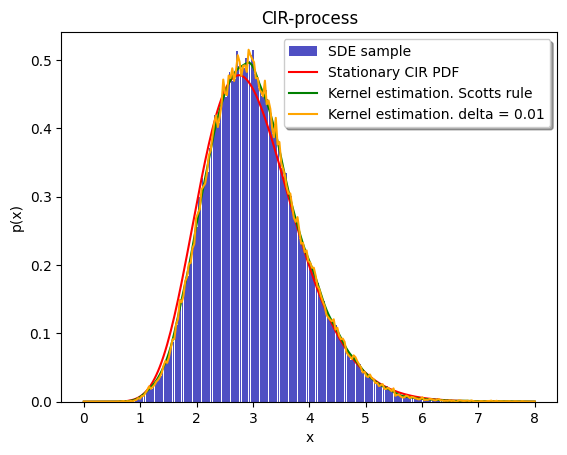

In [ ]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [ ]:
'''Расчёт на Nx траектриях'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

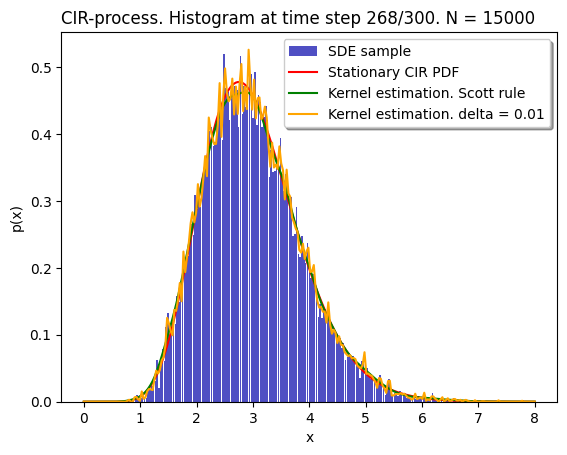

In [ ]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [ ]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [ ]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [ ]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [ ]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

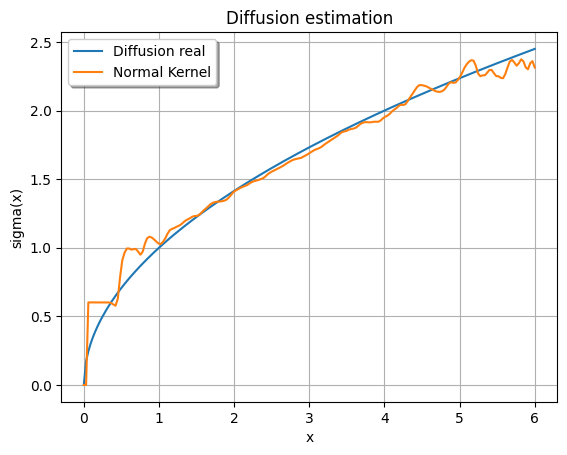

In [ ]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

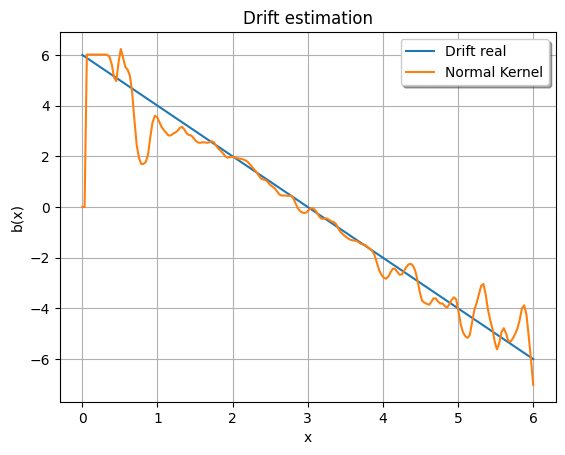

In [ ]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического).

4. Сделайте выводы.


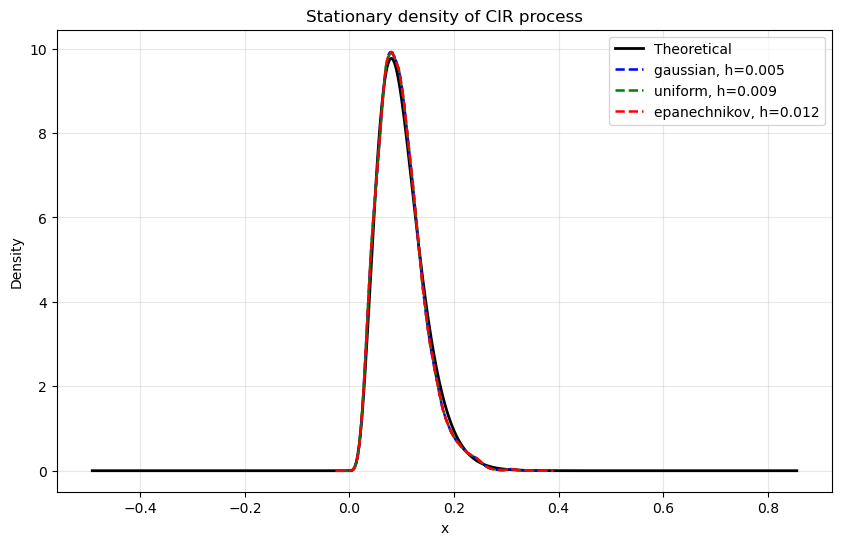

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def StationaryDistributionKernelEstimator(sample, kernel='gaussian', h=None, n_points=200):
    sample = np.asarray(sample)
    n = len(sample)
    if h is None:
        c = {'gaussian': 1.06, 'uniform': 1.84, 'epanechnikov': 2.34}[kernel]
        h = max(c * np.std(sample) * n**(-1/5), 1e-12)

    x_grid = np.linspace(sample.min() - 3*h, sample.max() + 3*h, n_points)

    kernels = {
        'gaussian':    lambda u: np.exp(-0.5*u**2) / np.sqrt(2*np.pi),
        'uniform':     lambda u: 0.5 * (np.abs(u) <= 1),
        'epanechnikov':lambda u: 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    }
    K = kernels[kernel]
    u = (x_grid[:, None] - sample[None, :]) / h
    f_est = np.mean(K(u), axis=1) / h
    return x_grid, f_est, h

params = [0.1, 1.0, 0.2]
cir = CIRprocess(params, T=500, Nx=1, Nt=50000, init_state=params[0]/params[1])
t, x = cir.ExactSolution()
sample = x.flatten()


x_theor = np.linspace(sample.min()-0.5, sample.max()+0.5, 500)
pi_theor = cir.StationaryDistribution(x_theor)


plt.figure(figsize=(10,6))
plt.plot(x_theor, pi_theor, 'k-', lw=2, label='Theoretical')
for ker, col in zip(['gaussian','uniform','epanechnikov'], ['blue','green','red']):
    xg, f, h = StationaryDistributionKernelEstimator(sample, kernel=ker)
    plt.plot(xg, f, '--', color=col, lw=1.8, label=f'{ker}, h={h:.3f}')
plt.xlabel('x'); plt.ylabel('Density')
plt.title('Stationary density of CIR process')
plt.legend(); plt.grid(alpha=0.3); plt.show()


### Влияние типа ядра
- Форма ядра слабо влияет на итоговую оценку при оптимально подобранной ширине окна.
- **Гауссовское ядро**: даёт наиболее гладкую оценку.
- **Равномерное ядро**: может давать слегка ступенчатую оценку.

### Автоматический выбор ширины окна
- Использование обобщённого правила Сильвермана с учётом констант для каждого ядра даёт визуально приемлемые результаты.
- Сравнительные значения ширины окна:
  - Наибольшая ширина — для ядра Епанечникова;
  - Наименьшая ширина — для гауссовского ядра.


Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



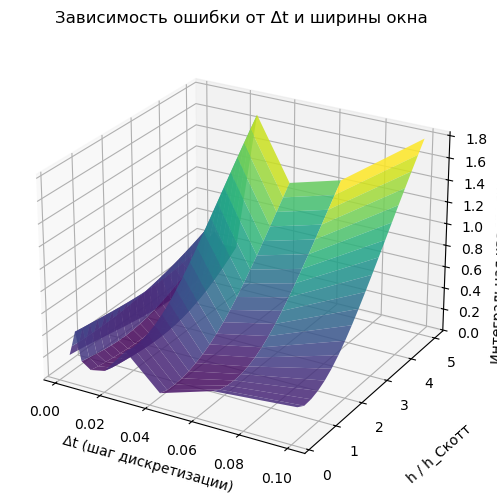

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def kde_gaussian(sample, h, x_grid):
    n = len(sample)
    u = (x_grid[:, None] - sample[None, :]) / h
    f = np.mean(np.exp(-0.5 * u**2), axis=1) / (h * np.sqrt(2 * np.pi))
    return f

params = [0.1, 1.0, 0.2]   
T = 100                        
x_grid = np.linspace(0, 0.4, 400)
dx = x_grid[1] - x_grid[0]    
cir_static = CIRprocess(params, 1, 1, 100)
pi_true = cir_static.StationaryDistribution(x_grid)


dt_vals = np.geomspace(0.002, 0.1, 10)      
mult_vals = np.linspace(0.2, 5.0, 20)      

errors = np.zeros((len(dt_vals), len(mult_vals)))

for i, dt in enumerate(dt_vals):
    Nt = int(T / dt)
    cir = CIRprocess(params, T, 1, Nt, init_state=params[0]/params[1])
    _, x = cir.ExactSolution()
    sample = x.flatten()
    n = len(sample)

    sigma_hat = np.std(sample)
    h_scott = 1.06 * sigma_hat * n**(-1/5)

    for j, mult in enumerate(mult_vals):
        h = mult * h_scott
        f_hat = kde_gaussian(sample, h, x_grid)
        ise = np.sum((f_hat - pi_true)**2) * dx
        errors[i, j] = ise

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(dt_vals, mult_vals)
Z = errors.T  

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax.set_xlabel('Δt (шаг дискретизации)')
ax.set_ylabel('h / h_Скотт', labelpad=20)
ax.set_zlabel('Интегральная квадратичная ошибка')
ax.set_title('Зависимость ошибки от Δt и ширины окна')
ax.view_init(elev=25, azim=-60)
plt.show()

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Сделайте выводы.


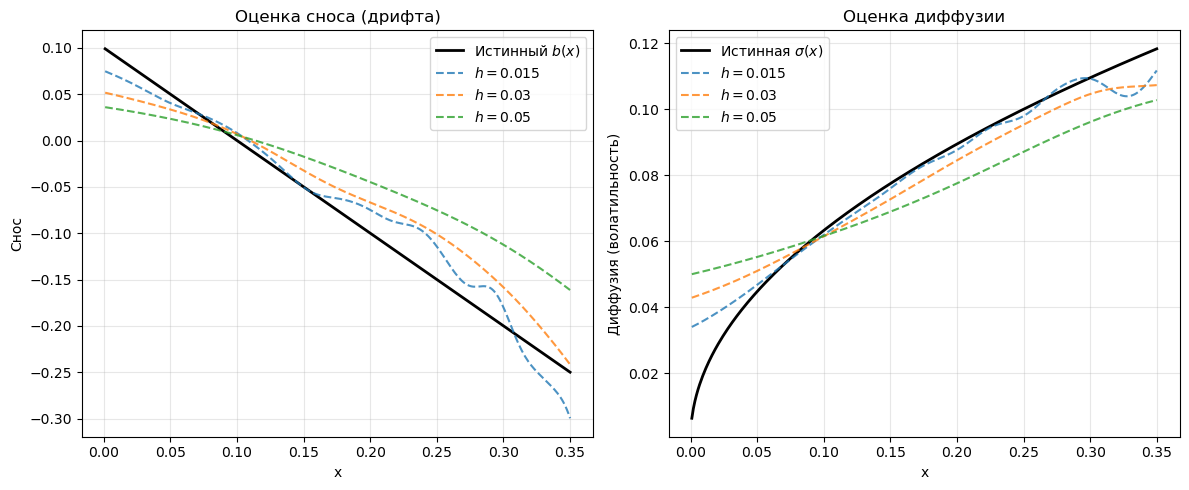

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def DriftKernelEstimator(x_grid, sample, dt, h):

    n = len(sample) - 1
    dX = np.diff(sample)
    X = sample[:-1]

    b_hat = np.zeros_like(x_grid)
    for j, x in enumerate(x_grid):
        u = (x - X) / h
        weights = gaussian_kernel(u)
        sum_weights = np.sum(weights)
        if sum_weights > 1e-12:
            b_hat[j] = np.sum(weights * dX) / (dt * sum_weights)
        else:
            b_hat[j] = 0.0  
    return b_hat
# Оценка квадрата диффузии 
def DiffusionKernelEstimator(x_grid, sample, dt, h):
    """
    Возвращает sigma2_hat(x_grid)
    """
    n = len(sample) - 1
    dX = np.diff(sample)
    X = sample[:-1]

    sigma2_hat = np.zeros_like(x_grid)
    for j, x in enumerate(x_grid):
        u = (x - X) / h
        weights = gaussian_kernel(u)
        sum_weights = np.sum(weights)
        if sum_weights > 1e-12:
            sigma2_hat[j] = np.sum(weights * dX**2) / (dt * sum_weights)
        else:
            sigma2_hat[j] = 0.0
    return sigma2_hat

params = [0.1, 1.0, 0.2] 
T = 500
dt = 0.01
Nt = int(T / dt)          

# Генерация одной траектории
cir = CIRprocess(params, T, 1, Nt, init_state=params[0]/params[1])
t, x = cir.ExactSolution()
sample = x.flatten()
# Истинные коэффициенты
def true_b(x):
    return params[0] - params[1] * x

def true_sigma(x):
    return params[2] * np.sqrt(np.maximum(x, 0))

x_grid = np.linspace(0.001, 0.35, 300)

h_values = [0.015, 0.03, 0.05]

# восстановление сноса

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_grid, true_b(x_grid), 'k-', linewidth=2, label='Истинный $b(x)$')
for h in h_values:
    b_hat = DriftKernelEstimator(x_grid, sample, dt, h)
    plt.plot(x_grid, b_hat, '--', alpha=0.8, label=f'$h={h}$')
plt.xlabel('x')
plt.ylabel('Снос')
plt.title('Оценка сноса (дрифта)')
plt.legend()
plt.grid(alpha=0.3)

# восстановление диффузии
plt.subplot(1, 2, 2)
plt.plot(x_grid, true_sigma(x_grid), 'k-', linewidth=2, label='Истинная $\sigma(x)$')
for h in h_values:
    sigma2_hat = DiffusionKernelEstimator(x_grid, sample, dt, h)
    sigma_hat = np.sqrt(np.maximum(sigma2_hat, 0))  # извлекаем σ
    plt.plot(x_grid, sigma_hat, '--', alpha=0.8, label=f'$h={h}$')
plt.xlabel('x')
plt.ylabel('Диффузия (волатильность)')
plt.title('Оценка диффузии')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы по оценке коэффициентов сноса и диффузии

### 1. Точность оценок в основной области
- Обе непараметрические оценки (сноса $\mu(x)$ и диффузии $\sigma(x)$) хорошо воспроизводят истинные функции в интервале сосредоточения основной массы наблюдений.
- Для процесса CIR с параметрами $\alpha=0.1$, $\beta=1.0$, $\sigma=0.2$:
  - Стационарное среднее: $\mathbb{E}[X] = \alpha/\beta = 0.1$;
  - Плотность быстро убывает при $x > 0.3$.
- На отрезке $[0.05, 0.25]$ непараметрические оценки практически совпадают с аналитическими кривыми.

### 2. Влияние ширины окна $h$
| Параметр | Малая ширина ($h=0.015$) | Большая ширина ($h$ увеличено) |
|----------|---------------------------|--------------------------------|
| **Чувствительность** | Точно отслеживает локальные особенности | Сглаживает локальные детали |
| **Дисперсия** | Высокая (больше шума) | Низкая (оценка стабильнее) |
| **Смещение** | Малое | Может возрастать в областях резкого изменения коэффициентов |
| **Риск** | Переобучение на шуме | Недообучение, потеря деталей |

- Особое внимание: вблизи нуля для $\sigma(x) = 0.2\sqrt{x}$ увеличение $h$ может приводить к смещению оценки из-за нелинейности истинной функции.



Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.
Приведите необходимые иллюстративные графики.

3. Сделайте выводы.



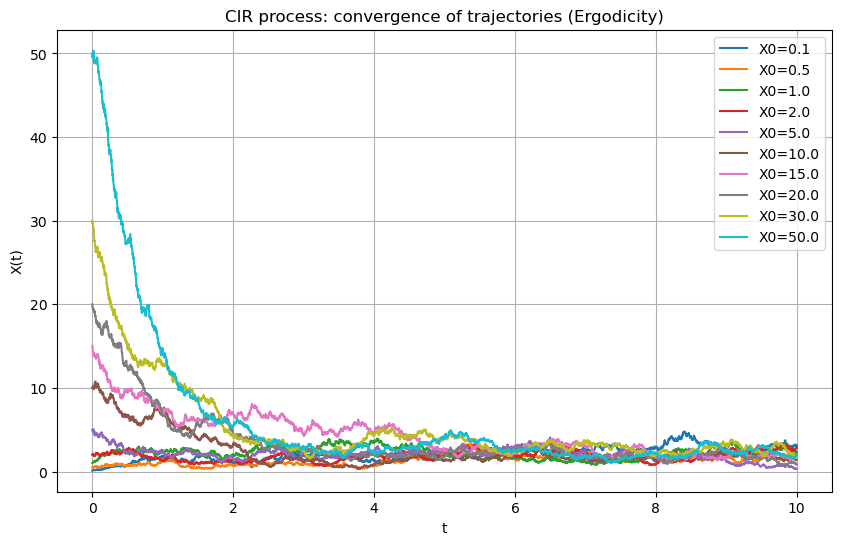

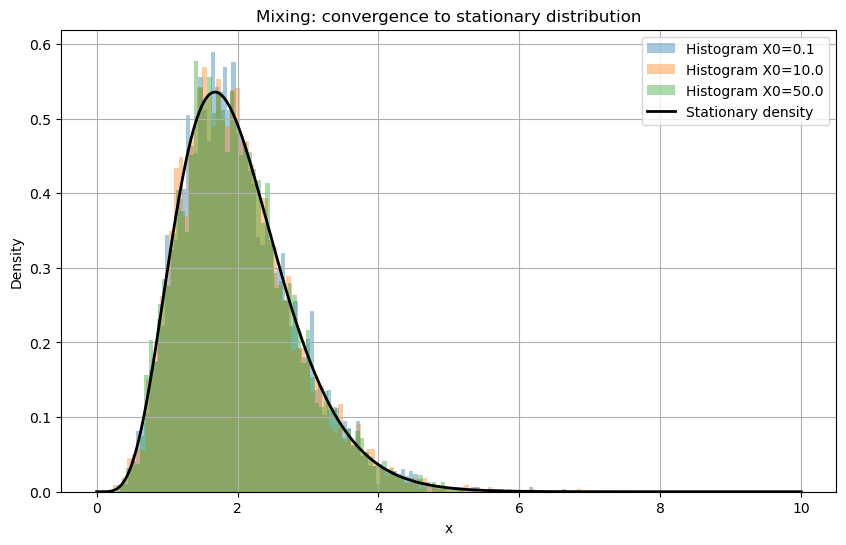

In [ ]:
theta1 = 2.0
theta2 = 1.0
theta3 = 0.8

params = [theta1, theta2, theta3]

T = 10.0       
Nt = 5000      
Nx = 1    

# начальные точки
initial_points = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0]

plt.figure(figsize=(10,6))

for x0 in initial_points:
    process = CIRprocess(params, T, Nx, Nt, init_state=np.array([x0]))
    t, x = process.EulerSolution()
    plt.plot(t, x[:,0], label=f"X0={x0}")

plt.title("CIR process: convergence of trajectories (Ergodicity)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.legend()
plt.grid()
plt.show()

Nx_large = 5000
T_large = 10.0
Nt_large = 5000

plt.figure(figsize=(10,6))

for x0 in [0.1, 10.0, 50.0]:  # сильно разные стартовые точки
    process = CIRprocess(params, T_large, Nx_large, Nt_large, 
                         init_state=x0*np.ones(Nx_large))
    t, x = process.EulerSolution()
    
    plt.hist(x[-1], bins=100, density=True, alpha=0.4,
             label=f"Histogram X0={x0}")

# стационарная плотность
x_grid = np.linspace(0, 10, 1000)
process = CIRprocess(params, T_large, Nx_large, Nt_large)
stationary_pdf = process.StationaryDistribution(x_grid)

plt.plot(x_grid, stationary_pdf, 'k', lw=2, label="Stationary density")

plt.title("Mixing: convergence to stationary distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

## Выводы

Траектории CIR-процесса, запущенные из существенно разных начальных точек, со временем сближаются и колеблются около одного и того же долгосрочного среднего, что подтверждает эргодичность процесса.

При достаточно большом времени распределения значений \( X(T) \), полученные из разных \( X_0 \), практически совпадают и стремятся к стационарной плотности. Это демонстрирует свойство перемешивания.

В долгосрочном режиме статистические свойства процесса определяются только параметрами модели и не зависят от начального состояния.

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Сделайте выводы.


KS-статистика: 0.0341, p-value: 0.0000
Ядерная оценка 90%-квантиля: 0.1676
Теоретический 90%-квантиль:    0.1599


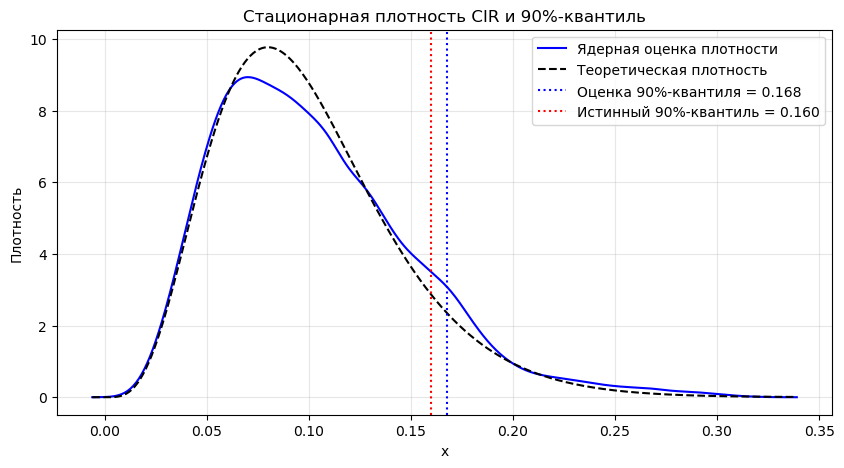

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, gamma

params = [0.1, 1.0, 0.2]          # alpha, beta, sigma
T = 500                           
dt = 0.01
Nt = int(T / dt)               

burn_in = int(0.5 * Nt)

cir = CIRprocess(params, T, 1, Nt, init_state=params[0]/params[1])
_, x = cir.ExactSolution()
sample = x.flatten()[burn_in:]   

# Критерий Колмогорова-Смирнова
shape_est = 2 * params[0] / params[2]**2   # 5
scale_est = params[2]**2 / (2 * params[1]) # 0.02

ks_stat, p_value = kstest(sample, 'gamma', args=(shape_est, 0, scale_est))
print(f"KS-статистика: {ks_stat:.4f}, p-value: {p_value:.4f}")

# Ядерная оценка плотности и расчёт 90%-квантиля
def StationaryDistributionKernelEstimator(sample, kernel='gaussian', h=None, n_points=200):
    sample = np.asarray(sample)
    n = len(sample)
    if h is None:
        c = {'gaussian': 1.06, 'uniform': 1.84, 'epanechnikov': 2.34}[kernel]
        h = max(c * np.std(sample) * n**(-1/5), 1e-12)
    x_grid = np.linspace(sample.min() - 3*h, sample.max() + 3*h, n_points)
    kernels = {
        'gaussian':    lambda u: np.exp(-0.5 * u**2) / np.sqrt(2*np.pi),
        'uniform':     lambda u: 0.5 * (np.abs(u) <= 1),
        'epanechnikov':lambda u: 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    }
    K = kernels[kernel]
    u = (x_grid[:, None] - sample[None, :]) / h
    f_est = np.mean(K(u), axis=1) / h
    return x_grid, f_est, h

x_grid, f_hat, h_used = StationaryDistributionKernelEstimator(sample, n_points=500)

dx = x_grid[1] - x_grid[0]
cdf_hat = np.cumsum(f_hat) * dx
cdf_hat = np.clip(cdf_hat, 0, 1)  

idx_q = np.searchsorted(cdf_hat, 0.9)
q_hat = x_grid[idx_q] if idx_q < len(x_grid) else x_grid[-1]

# Теоретический 90%-квантиль гамма-распределения
q_true = gamma.ppf(0.9, shape_est, scale=scale_est)
print(f"Ядерная оценка 90%-квантиля: {q_hat:.4f}")
print(f"Теоретический 90%-квантиль:    {q_true:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(x_grid, f_hat, 'b-', label='Ядерная оценка плотности')
plt.plot(x_grid, gamma.pdf(x_grid, shape_est, scale=scale_est), 'k--', label='Теоретическая плотность')
plt.axvline(q_hat, color='blue', linestyle=':', label=f'Оценка 90%-квантиля = {q_hat:.3f}')
plt.axvline(q_true, color='red', linestyle=':', label=f'Истинный 90%-квантиль = {q_true:.3f}')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Стационарная плотность CIR и 90%-квантиль')
plt.legend()
plt.grid(alpha=0.3)
plt.show()